In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Crete'
NUTS2_ID = 'EL43'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [4]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [7]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [8]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
12,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL431,Irakleio,Ηράκλειο,2.0,2,1,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35..."
13,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL432,Lasithi,Λασίθι,2.0,3,1,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35..."
14,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL433,Rethymni,Ρέθυμνο,3.0,3,1,"MULTIPOLYGON (((24.92800 35.40691, 24.92626 35..."
15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1,"MULTIPOLYGON (((24.31741 35.35377, 24.32346 35..."


<Axes: >

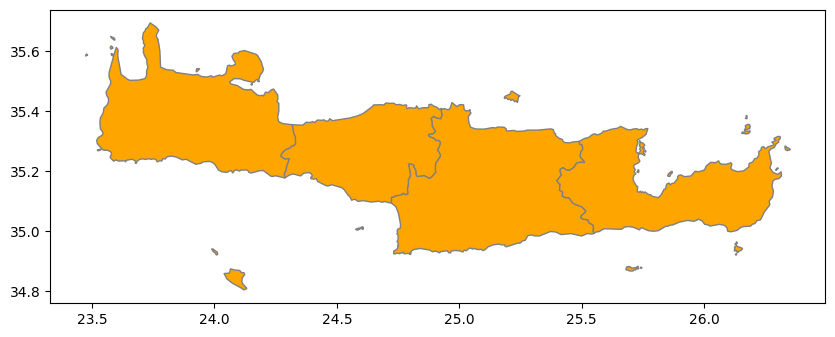

In [9]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [10]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

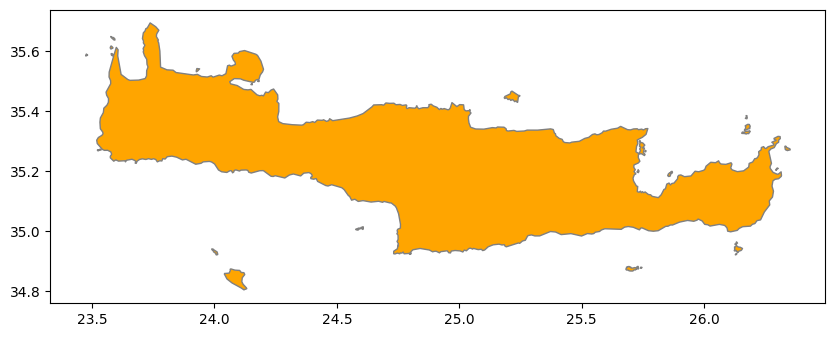

In [11]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [12]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [14]:
df_grid.shape

(1846, 5)

In [15]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((23.56139 35.28749, 23.56139 35.30545...",POINT (23.550451990270368 35.29647001900591),EL43,23.55045,35.29647
1,"POLYGON ((23.56139 35.34139, 23.56139 35.35935...",POINT (23.550451990270368 35.35037009380654),EL43,23.55045,35.35037
2,"POLYGON ((23.56139 35.35935, 23.56139 35.37732...",POINT (23.550451990270368 35.36833678540677),EL43,23.55045,35.36834
3,"POLYGON ((23.58327 35.26952, 23.58327 35.28749...",POINT (23.57233255891904 35.27850332740569),EL43,23.57233,35.27850
4,"POLYGON ((23.58327 35.28749, 23.58327 35.30545...",POINT (23.57233255891904 35.29647001900591),EL43,23.57233,35.29647


<Axes: >

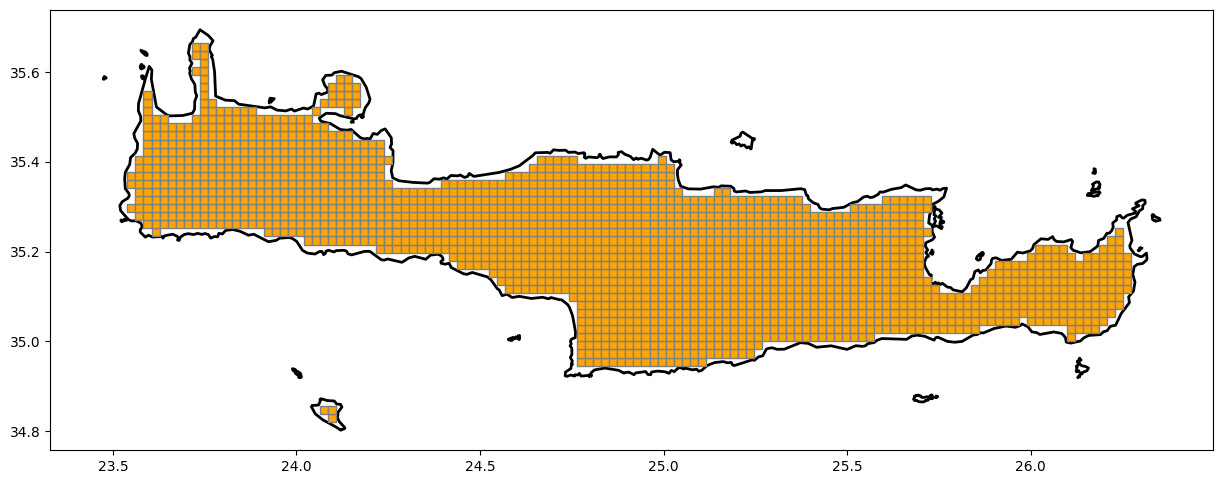

In [16]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [17]:
df_grid.set_geometry('centers', inplace=True)

In [18]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

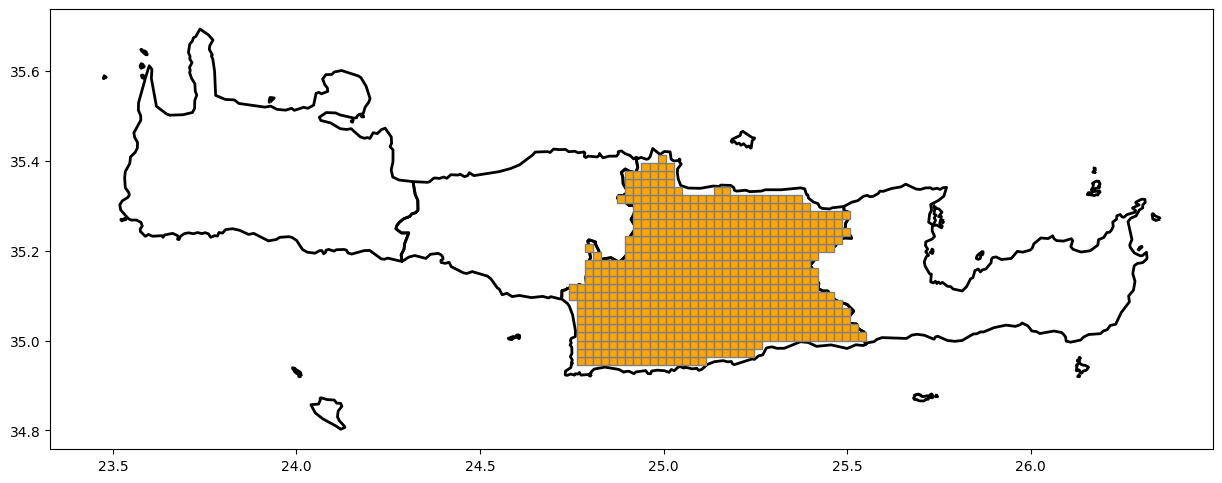

In [19]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL431'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((23.56139 35.28749, 23.56139 35.30545...",POINT (23.55045 35.29647),EL43,23.55045,35.29647,15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1
1,"POLYGON ((23.56139 35.34139, 23.56139 35.35935...",POINT (23.55045 35.35037),EL43,23.55045,35.35037,15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1
2,"POLYGON ((23.56139 35.35935, 23.56139 35.37732...",POINT (23.55045 35.36834),EL43,23.55045,35.36834,15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1
3,"POLYGON ((23.58327 35.26952, 23.58327 35.28749...",POINT (23.57233 35.27850),EL43,23.57233,35.27850,15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1
4,"POLYGON ((23.58327 35.28749, 23.58327 35.30545...",POINT (23.57233 35.29647),EL43,23.57233,35.29647,15,EL,Greece,EL4,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",EL43,Kriti,Κρήτη,EL434,Chania,Χανιά,2.0,2,1


In [21]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [22]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [23]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [24]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL43,κρητη,EL431,ηρακλειο,24.75388,35.09884,EL431000001,"POLYGON ((24.76482 35.08985, 24.76482 35.10782..."
1,EL43,κρητη,EL431,ηρακλειο,24.75388,35.11680,EL431000002,"POLYGON ((24.76482 35.10782, 24.76482 35.12579..."
2,EL43,κρητη,EL431,ηρακλειο,24.77576,34.95510,EL431000003,"POLYGON ((24.78670 34.94612, 24.78670 34.96409..."
3,EL43,κρητη,EL431,ηρακλειο,24.77576,34.97307,EL431000004,"POLYGON ((24.78670 34.96409, 24.78670 34.98205..."
4,EL43,κρητη,EL431,ηρακλειο,24.77576,34.99104,EL431000005,"POLYGON ((24.78670 34.98205, 24.78670 35.00002..."


In [25]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_{NUTS2}_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_{NUTS2}_Grid.shp', encoding = 'utf-8')